<a href="https://colab.research.google.com/github/aatayo/aatayo.github.io/blob/main/2D_PINN%20for%20Aluminum%20Cooling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2D PINN Cooling Fin Simulation (FIXED VERSION)
Thermal diffusivity   α = 8.23e-05 m²/s
Fin geometry          L × W × depth = 1.0 m × 0.1 m × 1.0 m
Cross-sectional area  A_cross = 0.100 m²  (half-fin)
Wetted perimeter      P = 2.10 m  (y=0 symmetry face excluded)
Conv. coeff (ref)     h_eff = 1050.00 W/(m³·K)  [ref only, not in PDE]
Initial temperature   T_initial = 323.0 K  (50°C)
Base temperature      T_base    = 373.0 K  (100°C)
Ambient temperature   T_inf     = 298.0 K  (25°C)
Simulation time       t_max = 5000.0 s

Dimensionless numbers:
  Biot number (x-direction): Bi_x = 0.2500
  Biot number (y-direction): Bi_y = 0.0250
  Fourier number:            Fo   = 0.41
  Fin parameter:             m    = 2.2913 m⁻¹
2D Physics-Informed Neural Network — Aluminum Cooling Fin

FIXES APPLIED IN THIS VERSION:
  FIX 1  — Removed volumetric conv term from 2D PDE (pure diffusion)
  FIX 2  — Analytical validation uses convective-tip formula
  FIX 3  — Adaptive weights via tf.Variable (no @tf.functi

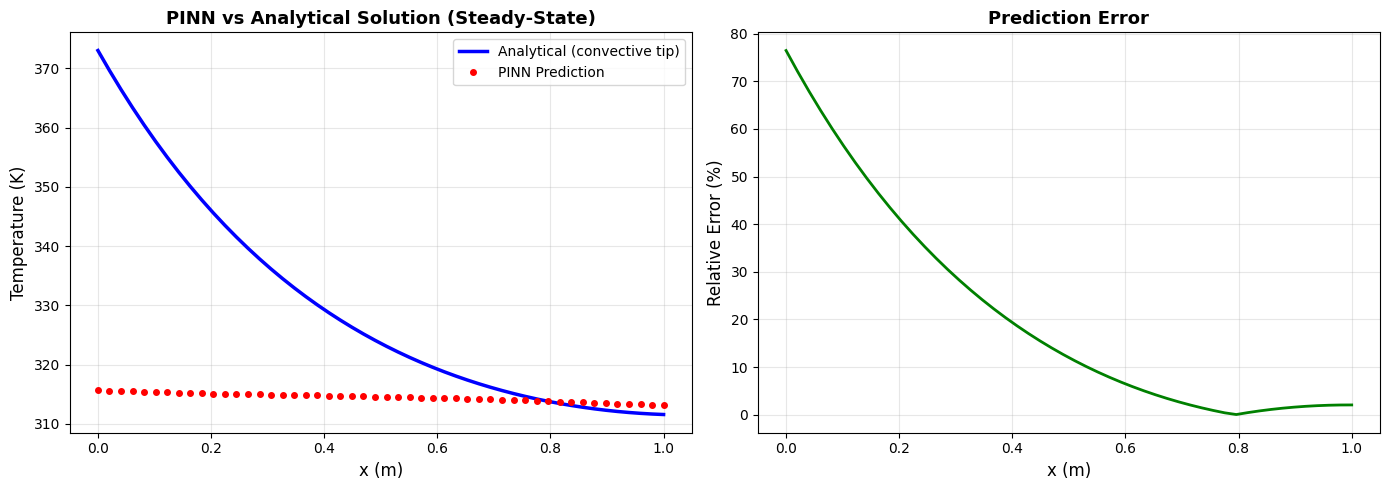

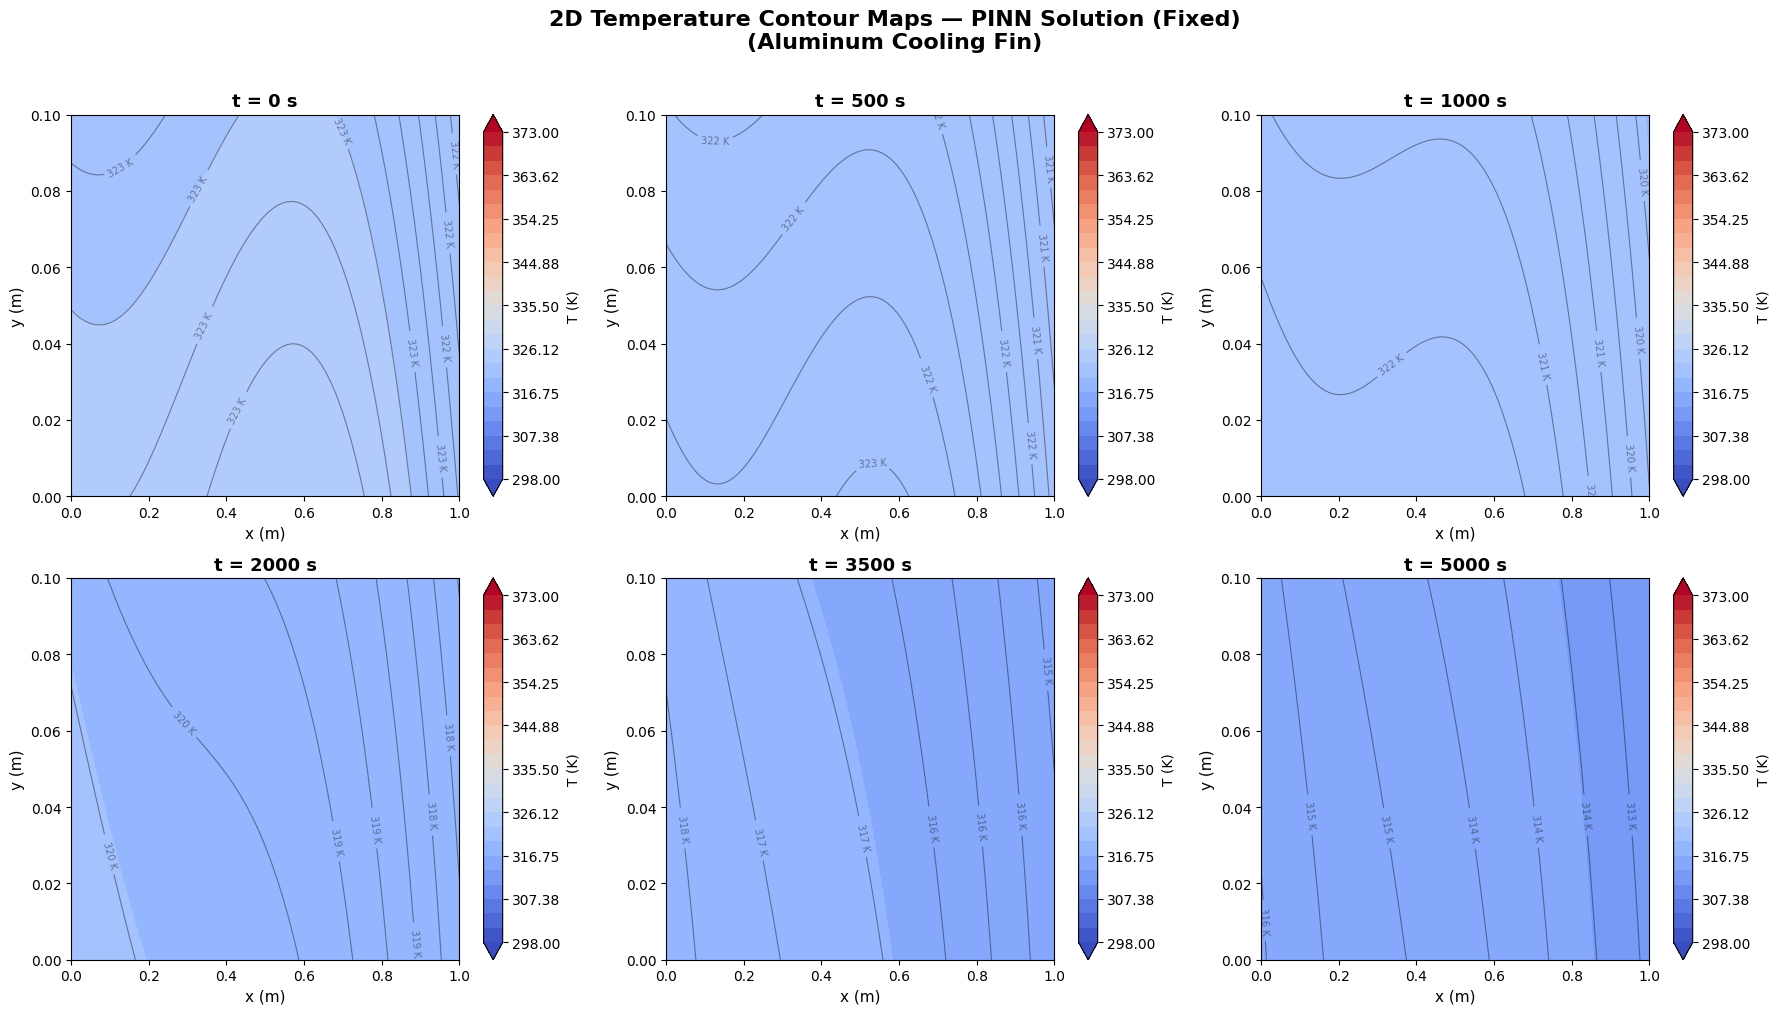

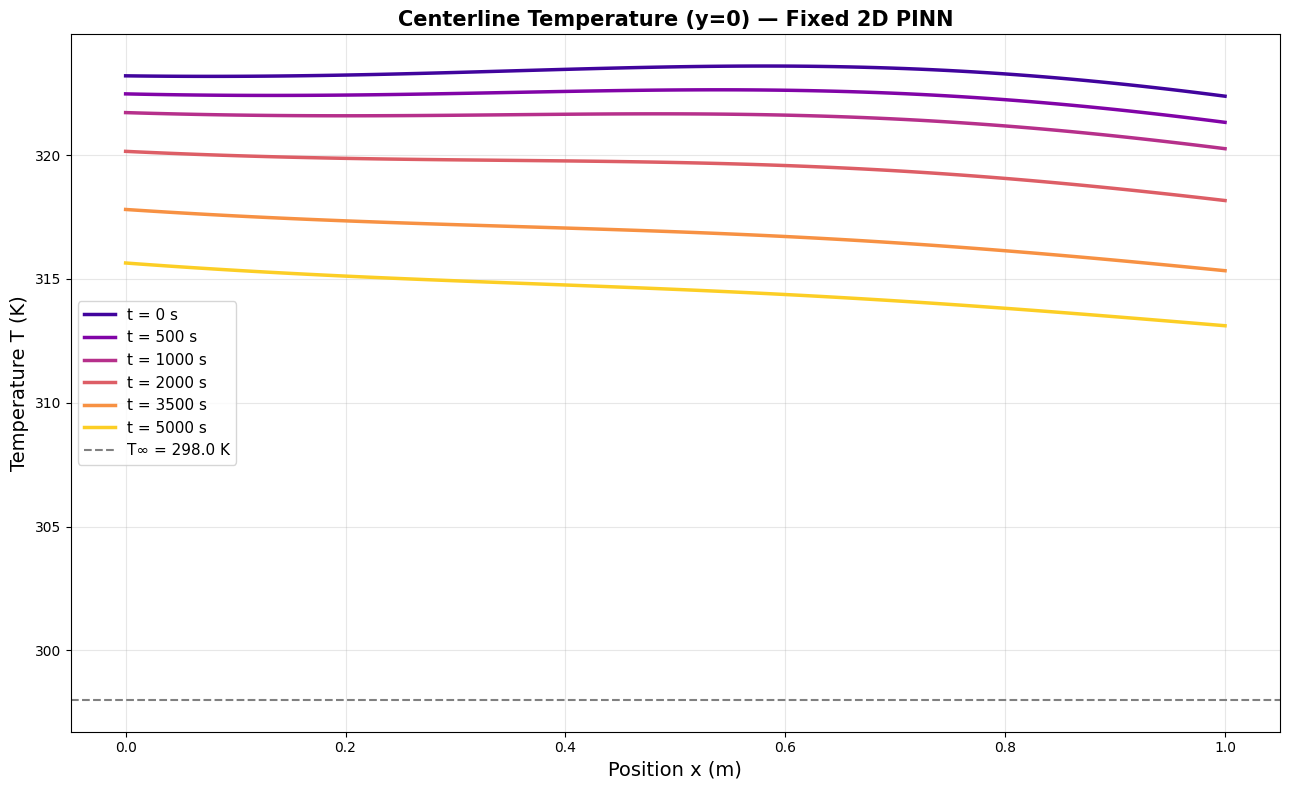

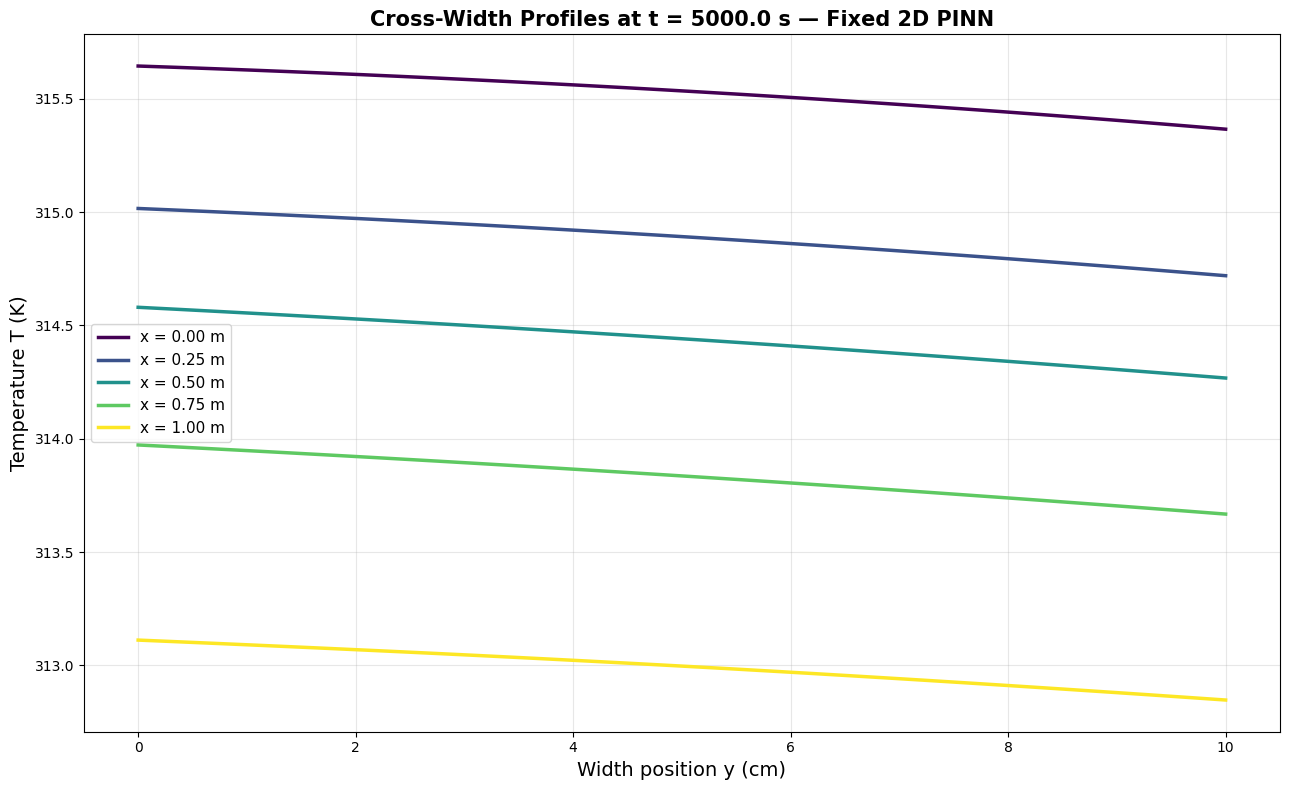

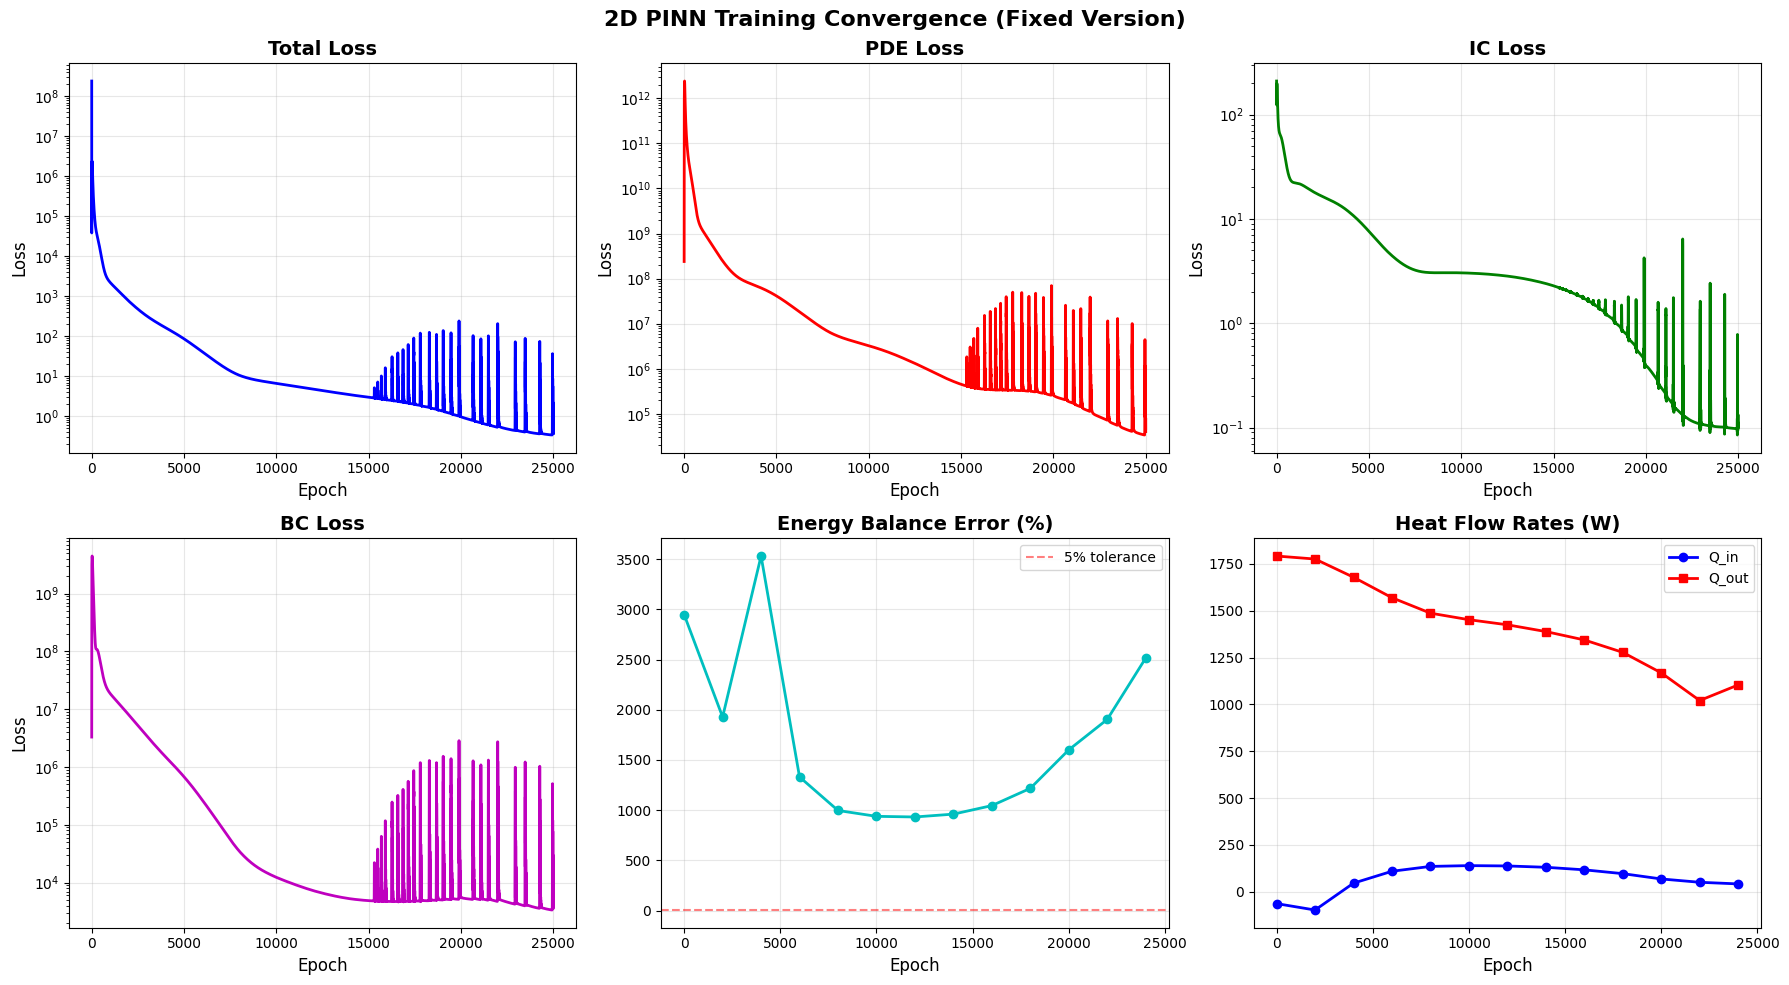

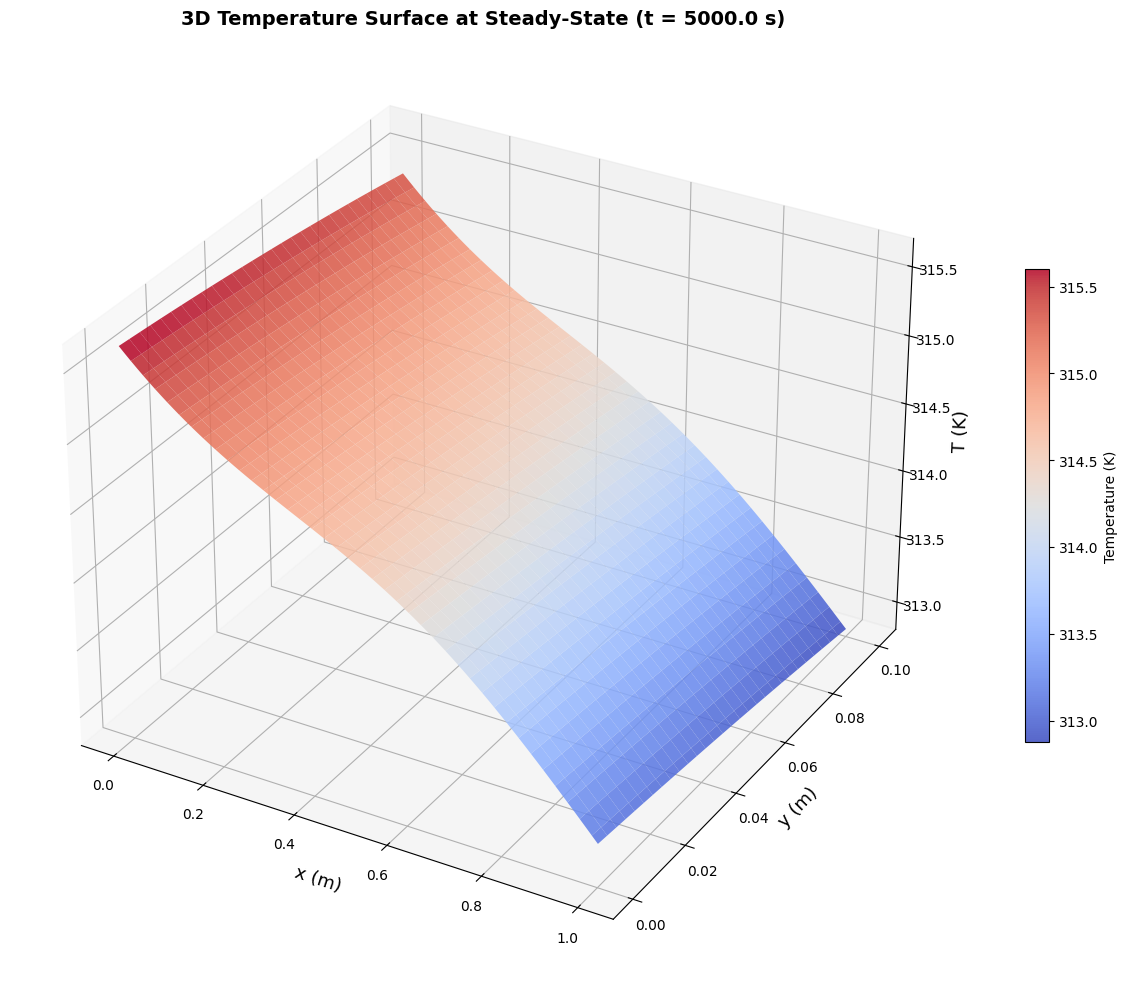


2D HEAT TRANSFER ANALYSIS (FIXED VERSION)
Biot number (x):   Bi_x = 0.2500
Biot number (y):   Bi_y = 0.0250
Fourier number:    Fo   = 0.41
Fin parameter:     m    = 2.2913 m⁻¹
✓ Fourier number > 0.2 — steady-state likely achieved

Final State at t = 5000.0 s:
  Max temperature : 315.65 K  (42.50°C)
  Min temperature : 312.85 K  (39.70°C)
  Avg temperature : 314.35 K  (41.20°C)
  Temperature drop: 2.80 K

Fin Performance:
  Fin efficiency : 0.218 (21.8%)

Energy Balance (final):
  Q_in (base flux) : 42.205 W
  Q_out (convect.) : 1103.974 W
  Balance error    : 2515.77%

VERIFICATION CHECKS
Base temperature : 319.209 K  (expected 373.000 K, error 53.7910 K)
Symmetry check   : dT/dy ≈ -2.9907 K/m at y≈0 (should be ≈0)
Steady-state     : ΔT/Δt ≈ 0.00136 K/s  ✓

SIMULATION COMPLETE
Final total loss : 3.70e-01
Final PDE loss   : 4.05e+04
Final IC  loss   : 1.02e-01
Final BC  loss   : 3.65e+03


In [5]:
# =============================================================================
# Physics-Informed Neural Network (PINN) for 2D Cooling Fin Heat Transfer
# =============================================================================
# This script extends the 1D PINN formulation to a fully two-dimensional
# aluminum cooling fin. The network solves the transient 2D heat conduction
# PDE with convective losses along all exposed surfaces. Input dimensions
# are (x, y, t) and the output is the temperature field T(x, y, t).
#
# Governing PDE (CORRECTED — no volumetric convection term):
#   ρ·cₚ · ∂T/∂t = k·(∂²T/∂x² + ∂²T/∂y²)
#
# Boundary Conditions:
#   T(0, y, t)   = T_base                    (Dirichlet: heated base at x=0)
#   k·∂T/∂x + h·(T − T∞) = 0  at x=L       (Robin: convective tip)
#   ∂T/∂y = 0                  at y=0        (Neumann: symmetry plane)
#   k·∂T/∂y + h·(T − T∞) = 0  at y=W       (Robin: convective side)
#
# Initial Condition:
#   T(x, y, 0) = T_initial     (Uniform initial temperature)
#
# FIXES APPLIED:
#   FIX 1  — Removed incorrect volumetric convection term from 2D PDE
#   FIX 2  — Corrected analytical validation to use convective-tip formula
#   FIX 3  — Adaptive loss weighting moved outside @tf.function using tf.Variable
#   FIX 4  — Corrected P_wetted for geometry with y=0 symmetry plane
#   FIX W1 — Domain verification uses y=+epsilon only (y<0 is outside domain)
#   FIX W2 — T_initial != T_base so IC and base BC provide distinct gradient signal
#   FIX W3 — Removed unused 'from numpy import cosh' import
#   FIX W4 — epoch no longer passed into @tf.function (avoids retracing)
# =============================================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import time
import warnings
warnings.filterwarnings('ignore')

# --- Plotting Configuration ---
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# --- Reproducibility ---
np.random.seed(42)
tf.random.set_seed(42)

# =============================================================================
# PHYSICAL PARAMETERS (2D Aluminum Fin)
# =============================================================================
rho    = 2700.0    # Density [kg/m³]
c_p    = 900.0     # Specific heat capacity [J/(kg·K)]
k      = 200.0     # Thermal conductivity [W/(m·K)]
h      = 50.0      # Convective heat transfer coefficient [W/(m²·K)]
T_inf  = 298.0     # Ambient temperature [K] = 25°C
L      = 1.0       # Fin length in x-direction [m]
W      = 0.1       # Fin half-width in y-direction [m]  (y=0 is symmetry plane)
depth  = 1.0       # Fin depth [m] (per unit length)

# FIX 4: Correct P/A for geometry where y=0 is a symmetry plane.
# The domain [0,W] represents half the fin; the y=0 face is NOT convective.
# Exposed surfaces per unit length in x: one side face (y=W, area=depth*dx)
# plus two depth faces (z=0 and z=depth, area=W*dx each).
# For a thin fin (depth >> W), the standard formulation uses the full cross-section.
# Here we model the half-fin with correct surfaces:
#   - Top/bottom (depth faces): 2 * depth  per unit x  [exposed]
#   - Side (y=W face):          1 * depth  per unit x  [exposed via Robin BC]
#   - Symmetry (y=0 face):      NOT convective
A_cross  = W * depth                   # Half-fin cross-sectional area [m²]
P_wetted = 2 * depth + W               # FIX 4: exclude y=0 symmetry face [m]
#   (2*depth = top+bottom faces; W = one side face. Multiply by dx for fin strip.)

# NOTE: conv_coeff is retained for reference / energy-balance calculations
# but is NO LONGER added to the PDE interior (FIX 1).
conv_coeff_ref = h * P_wetted / A_cross   # Reference fin parameter [W/(m³·K)]

# FIX W2: Distinct initial and base temperatures so IC ≠ BC
T_initial = 323.0  # Initial uniform temperature [K] = 50°C
T_base    = 373.0  # Fixed base temperature at x=0 [K] = 100°C

# --- Simulation time (extended to reach steady-state) ---
t_max  = 5000.0    # [s]

# --- Derived Parameters ---
alpha  = k / (rho * c_p)               # Thermal diffusivity [m²/s]

print("=" * 70)
print("2D PINN Cooling Fin Simulation (FIXED VERSION)")
print("=" * 70)
print(f"Thermal diffusivity   α = {alpha:.2e} m²/s")
print(f"Fin geometry          L × W × depth = {L} m × {W} m × {depth} m")
print(f"Cross-sectional area  A_cross = {A_cross:.3f} m²  (half-fin)")
print(f"Wetted perimeter      P = {P_wetted:.2f} m  (y=0 symmetry face excluded)")
print(f"Conv. coeff (ref)     h_eff = {conv_coeff_ref:.2f} W/(m³·K)  [ref only, not in PDE]")
print(f"Initial temperature   T_initial = {T_initial} K  ({T_initial-273.15:.0f}°C)")
print(f"Base temperature      T_base    = {T_base} K  ({T_base-273.15:.0f}°C)")
print(f"Ambient temperature   T_inf     = {T_inf} K  ({T_inf-273.15:.0f}°C)")
print(f"Simulation time       t_max = {t_max} s")

Bi_x = h * L / k
Bi_y = h * W / k
Fo   = alpha * t_max / L**2
m_analytical = np.sqrt(conv_coeff_ref / k)   # Fin parameter for convective-tip formula
print(f"\nDimensionless numbers:")
print(f"  Biot number (x-direction): Bi_x = {Bi_x:.4f}")
print(f"  Biot number (y-direction): Bi_y = {Bi_y:.4f}")
print(f"  Fourier number:            Fo   = {Fo:.2f}")
print(f"  Fin parameter:             m    = {m_analytical:.4f} m⁻¹")


# =============================================================================
# 2D PINN CLASS (FIXED)
# =============================================================================
class CoolingFin2DPINN:
    def __init__(self, layers, lb, ub):
        """
        2D Physics-Informed Neural Network for transient fin heat transfer.

        Args:
            layers : List[int] — network architecture [3, ..., 1]
            lb     : List[float] — lower bounds [x_min, y_min, t_min]
            ub     : List[float] — upper bounds [x_max, y_max, t_max]
        """
        self.layers = layers
        self.lb     = tf.constant(lb, dtype=tf.float32)
        self.ub     = tf.constant(ub, dtype=tf.float32)

        self.loss_history     = []
        self.pde_loss_history = []
        self.ic_loss_history  = []
        self.bc_loss_history  = []
        self.energy_balance_history = []

        # FIX 3: tf.Variable placeholders for adaptive loss weights.
        # Updated in Python (outside @tf.function) after the first batch.
        self.w_pde = tf.Variable(1.0, trainable=False, dtype=tf.float32)
        self.w_ic  = tf.Variable(1.0, trainable=False, dtype=tf.float32)
        self.w_bc  = tf.Variable(1.0, trainable=False, dtype=tf.float32)
        self._weights_initialized = False

        self.weights, self.biases = self._initialize_network()

    # -------------------------------------------------------------------------
    def _initialize_network(self):
        weights, biases = [], []
        for i in range(len(self.layers) - 1):
            fan_in, fan_out = self.layers[i], self.layers[i + 1]
            scale = np.sqrt(2.0 / (fan_in + fan_out))
            w = tf.Variable(
                tf.random.normal([fan_in, fan_out], dtype=tf.float32) * scale,
                trainable=True)
            b = tf.Variable(tf.zeros([fan_out], dtype=tf.float32), trainable=True)
            weights.append(w)
            biases.append(b)
        return weights, biases

    # -------------------------------------------------------------------------
    def neural_net(self, X):
        """
        Forward pass: normalize (x,y,t) → [-1,1], tanh hidden layers,
        sigmoid output scaled to [T_inf, T_base].
        """
        X_norm = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0
        H = X_norm
        for i in range(len(self.weights) - 1):
            H = tf.tanh(tf.matmul(H, self.weights[i]) + self.biases[i])
        raw = tf.matmul(H, self.weights[-1]) + self.biases[-1]
        # Sigmoid bounds output to physical range [T_inf, T_base]
        T = T_inf + (T_base - T_inf) * tf.sigmoid(raw)
        return T

    # -------------------------------------------------------------------------
    def pde_residual(self, x, y, t):
        """
        FIX 1: 2D transient heat conduction WITHOUT volumetric convection.

        PDE: ρ·cₚ · ∂T/∂t = k·(∂²T/∂x² + ∂²T/∂y²)

        Convection is handled purely through Robin BCs at the boundaries.
        """
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch([x, y, t])
            with tf.GradientTape(persistent=True) as tape1:
                tape1.watch([x, y, t])
                X = tf.concat([x, y, t], axis=1)
                T = self.neural_net(X)
            T_x = tape1.gradient(T, x)
            T_y = tape1.gradient(T, y)
            T_t = tape1.gradient(T, t)
        T_xx = tape2.gradient(T_x, x)
        T_yy = tape2.gradient(T_y, y)
        del tape1, tape2

        # Pure diffusion PDE residual (no volumetric conv term)
        residual = rho * c_p * T_t - k * (T_xx + T_yy)
        return residual, T

    # -------------------------------------------------------------------------
    def get_trainable_variables(self):
        return self.weights + self.biases

    # -------------------------------------------------------------------------
    def _update_adaptive_weights(self, loss_pde, loss_ic, loss_bc):
        """
        FIX 3: Compute and store adaptive weights in tf.Variables
        from OUTSIDE @tf.function so Python-level logic works correctly.
        Only called once, after the very first forward pass.
        """
        eps = 1e-8
        w_p = 1.0 / (float(loss_pde) + eps)
        w_i = 1.0 / (float(loss_ic)  + eps)
        w_b = 1.0 / (float(loss_bc)  + eps)
        total = w_p + w_i + w_b
        self.w_pde.assign(w_p / total)
        self.w_ic.assign(w_i  / total)
        self.w_bc.assign(w_b  / total)

    # -------------------------------------------------------------------------
    @tf.function
    def loss_function(self, x_pde, y_pde, t_pde,
                      x_ic, y_ic, t_ic, T_ic,
                      x_bc_base, y_bc_base, t_bc_base, T_bc_base,
                      x_bc_tip, y_bc_tip, t_bc_tip,
                      x_bc_sym, y_bc_sym, t_bc_sym,
                      x_bc_side, y_bc_side, t_bc_side):
        """
        Composite loss:
          1. PDE residual (interior)
          2. Initial condition
          3. Dirichlet base BC
          4. Robin tip BC  (x=L)
          5. Neumann symmetry BC (y=0)
          6. Robin side BC  (y=W)

        Weights are read from tf.Variables (set externally — FIX 3).
        FIX W4: epoch is NOT passed here, eliminating retracing.
        """
        # 1. PDE
        res, _ = self.pde_residual(x_pde, y_pde, t_pde)
        loss_pde = tf.reduce_mean(tf.square(res))

        # 2. IC
        X_ic      = tf.concat([x_ic, y_ic, t_ic], axis=1)
        T_pred_ic = self.neural_net(X_ic)
        loss_ic   = tf.reduce_mean(tf.square(T_pred_ic - T_ic))

        # 3. Base Dirichlet
        X_base       = tf.concat([x_bc_base, y_bc_base, t_bc_base], axis=1)
        T_pred_base  = self.neural_net(X_base)
        loss_bc_base = tf.reduce_mean(tf.square(T_pred_base - T_bc_base))

        # 4. Tip Robin: k·∂T/∂x + h·(T − T∞) = 0
        with tf.GradientTape() as tape_tip:
            tape_tip.watch(x_bc_tip)
            X_tip      = tf.concat([x_bc_tip, y_bc_tip, t_bc_tip], axis=1)
            T_pred_tip = self.neural_net(X_tip)
        dT_dx_tip   = tape_tip.gradient(T_pred_tip, x_bc_tip)
        res_tip     = k * dT_dx_tip + h * (T_pred_tip - T_inf)
        loss_bc_tip = tf.reduce_mean(tf.square(res_tip))

        # 5. Symmetry Neumann: ∂T/∂y = 0 at y=0
        with tf.GradientTape() as tape_sym:
            tape_sym.watch(y_bc_sym)
            X_sym      = tf.concat([x_bc_sym, y_bc_sym, t_bc_sym], axis=1)
            T_pred_sym = self.neural_net(X_sym)
        dT_dy_sym   = tape_sym.gradient(T_pred_sym, y_bc_sym)
        loss_bc_sym = tf.reduce_mean(tf.square(dT_dy_sym))

        # 6. Side Robin: k·∂T/∂y + h·(T − T∞) = 0 at y=W
        with tf.GradientTape() as tape_side:
            tape_side.watch(y_bc_side)
            X_side      = tf.concat([x_bc_side, y_bc_side, t_bc_side], axis=1)
            T_pred_side = self.neural_net(X_side)
        dT_dy_side   = tape_side.gradient(T_pred_side, y_bc_side)
        res_side     = k * dT_dy_side + h * (T_pred_side - T_inf)
        loss_bc_side = tf.reduce_mean(tf.square(res_side))

        loss_bc_total = loss_bc_base + loss_bc_tip + loss_bc_sym + loss_bc_side

        # FIX 3: Use tf.Variable weights (set externally, no Python logic here)
        loss_total = (self.w_pde * loss_pde
                      + self.w_ic  * loss_ic
                      + self.w_bc  * loss_bc_total)

        return loss_total, loss_pde, loss_ic, loss_bc_total

    # -------------------------------------------------------------------------
    @tf.function
    def _train_step_graph(self, optimizer, *args):
        with tf.GradientTape() as tape:
            loss_total, loss_pde, loss_ic, loss_bc = self.loss_function(*args)
        grads = tape.gradient(loss_total, self.get_trainable_variables())
        optimizer.apply_gradients(zip(grads, self.get_trainable_variables()))
        return loss_total, loss_pde, loss_ic, loss_bc

    def train_step(self, optimizer, *args):
        return self._train_step_graph(optimizer, *args)

    # -------------------------------------------------------------------------
    def compute_energy_balance(self):
        """
        Approximate energy balance validation at steady-state mid-time.
        Q_in: heat flux at base (x=0); Q_out: convection at tip + side.
        """
        n = 200

        # Heat flux at base via auto-diff
        x_base_eb = tf.zeros((n, 1), dtype=tf.float32)
        y_base_eb = tf.cast(tf.linspace(0.0, W, n)[:, None], tf.float32)
        t_base_eb = (t_max / 2) * tf.ones((n, 1), dtype=tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(x_base_eb)
            T_b = self.neural_net(tf.concat([x_base_eb, y_base_eb, t_base_eb], 1))
        dT_dx_b = tape.gradient(T_b, x_base_eb)
        # Integrate over y: Q_in = -k * dT/dx * depth, averaged over W
        Q_in = float(tf.reduce_mean(-k * dT_dx_b * depth * W))

        # Convection at tip (x=L)
        x_tip_eb = L * tf.ones((n, 1), dtype=tf.float32)
        y_tip_eb = tf.cast(tf.linspace(0.0, W, n)[:, None], tf.float32)
        t_tip_eb = (t_max / 2) * tf.ones((n, 1), dtype=tf.float32)
        T_tip_eb = self.neural_net(tf.concat([x_tip_eb, y_tip_eb, t_tip_eb], 1))
        Q_tip = float(h * depth * W * tf.reduce_mean(T_tip_eb - T_inf))

        # Convection at side (y=W)
        x_side_eb = tf.cast(tf.linspace(0.0, L, n)[:, None], tf.float32)
        y_side_eb = W * tf.ones((n, 1), dtype=tf.float32)
        t_side_eb = (t_max / 2) * tf.ones((n, 1), dtype=tf.float32)
        T_side_eb = self.neural_net(tf.concat([x_side_eb, y_side_eb, t_side_eb], 1))
        Q_side = float(h * depth * L * tf.reduce_mean(T_side_eb - T_inf))

        Q_out = Q_tip + Q_side
        balance_error = abs(Q_in - Q_out) / (abs(Q_in) + 1e-8) * 100
        return Q_in, Q_out, balance_error

    # -------------------------------------------------------------------------
    def train(self, training_data, epochs=25000, lr=0.001):
        """
        Training loop with exponential LR decay and adaptive weight init.
        """
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=lr,
            decay_steps=2000,
            decay_rate=0.95,
            staircase=True)
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

        args = (
            training_data['x_pde'],    training_data['y_pde'],    training_data['t_pde'],
            training_data['x_ic'],     training_data['y_ic'],     training_data['t_ic'],
            training_data['T_ic'],
            training_data['x_base'],   training_data['y_base'],   training_data['t_base'],
            training_data['T_base'],
            training_data['x_tip'],    training_data['y_tip'],    training_data['t_tip'],
            training_data['x_sym'],    training_data['y_sym'],    training_data['t_sym'],
            training_data['x_side'],   training_data['y_side'],   training_data['t_side'],
        )

        print("\nStarting 2D PINN training...")
        start = time.time()

        for epoch in range(epochs):
            loss_total, loss_pde, loss_ic, loss_bc = self.train_step(optimizer, *args)

            # FIX 3: initialise adaptive weights after first forward pass
            if not self._weights_initialized:
                self._update_adaptive_weights(loss_pde, loss_ic, loss_bc)
                self._weights_initialized = True

            self.loss_history.append(float(loss_total))
            self.pde_loss_history.append(float(loss_pde))
            self.ic_loss_history.append(float(loss_ic))
            self.bc_loss_history.append(float(loss_bc))

            if epoch % 2000 == 0:
                elapsed = time.time() - start
                Q_in, Q_out, eb_err = self.compute_energy_balance()
                self.energy_balance_history.append(
                    {'epoch': epoch, 'Q_in': Q_in, 'Q_out': Q_out, 'error': eb_err})
                print(f"  Epoch {epoch:5d} | Total={loss_total:.2e} | "
                      f"PDE={loss_pde:.2e} | IC={loss_ic:.2e} | "
                      f"BC={loss_bc:.2e} | t={elapsed:.1f}s")
                print(f"           Energy Balance: "
                      f"Q_in={Q_in:.2f} W  Q_out={Q_out:.2f} W  Err={eb_err:.1f}%")

        print(f"\nTraining complete in {time.time()-start:.1f}s")
        return self.loss_history

    # -------------------------------------------------------------------------
    def predict(self, x, y, t):
        X = tf.concat([x, y, t], axis=1)
        return self.neural_net(X)


# =============================================================================
# TRAINING DATA GENERATION
# =============================================================================
def generate_2d_training_data():
    def to_tf(*arrays):
        return [tf.constant(a, dtype=tf.float32) for a in arrays]

    n_pde  = 20000
    x_pde  = np.random.uniform(0, L,     (n_pde, 1))
    y_pde  = np.random.uniform(0, W,     (n_pde, 1))
    t_pde  = np.random.uniform(0, t_max, (n_pde, 1))

    n_ic   = 3000
    x_ic   = np.random.uniform(0, L, (n_ic, 1))
    y_ic   = np.random.uniform(0, W, (n_ic, 1))
    t_ic   = np.zeros((n_ic, 1))
    T_ic   = T_initial * np.ones((n_ic, 1))      # FIX W2: T_initial != T_base

    n_base = 1000
    x_base = np.zeros((n_base, 1))
    y_base = np.random.uniform(0, W,     (n_base, 1))
    t_base = np.random.uniform(0, t_max, (n_base, 1))
    T_bval = T_base * np.ones((n_base, 1))

    n_tip  = 1000
    x_tip  = L * np.ones((n_tip, 1))
    y_tip  = np.random.uniform(0, W,     (n_tip, 1))
    t_tip  = np.random.uniform(0, t_max, (n_tip, 1))

    n_sym  = 800
    x_sym  = np.random.uniform(0, L,     (n_sym, 1))
    y_sym  = np.zeros((n_sym, 1))
    t_sym  = np.random.uniform(0, t_max, (n_sym, 1))

    n_side = 800
    x_side = np.random.uniform(0, L,     (n_side, 1))
    y_side = W * np.ones((n_side, 1))
    t_side = np.random.uniform(0, t_max, (n_side, 1))

    print(f"\nTraining data summary:")
    print(f"  PDE collocation : {n_pde}")
    print(f"  Initial cond.   : {n_ic}  (T_initial = {T_initial} K)")
    print(f"  Base BC (x=0)   : {n_base}  (T_base = {T_base} K)")
    print(f"  Tip BC  (x=L)   : {n_tip}")
    print(f"  Sym  BC (y=0)   : {n_sym}")
    print(f"  Side BC (y=W)   : {n_side}")

    data = {}
    data['x_pde'],  data['y_pde'],  data['t_pde']              = to_tf(x_pde,  y_pde,  t_pde)
    data['x_ic'],   data['y_ic'],   data['t_ic'],  data['T_ic'] = to_tf(x_ic,   y_ic,   t_ic, T_ic)
    data['x_base'], data['y_base'], data['t_base'],data['T_base']= to_tf(x_base, y_base, t_base, T_bval)
    data['x_tip'],  data['y_tip'],  data['t_tip']               = to_tf(x_tip,  y_tip,  t_tip)
    data['x_sym'],  data['y_sym'],  data['t_sym']               = to_tf(x_sym,  y_sym,  t_sym)
    data['x_side'], data['y_side'], data['t_side']              = to_tf(x_side, y_side, t_side)
    return data


# =============================================================================
# ANALYTICAL VALIDATION
# =============================================================================
def analytical_1d_convective_tip(x, m_fin, L_fin, T_base_val, T_inf_val, h_val, k_val):
    """
    FIX 2: Analytical 1D fin solution with CONVECTIVE tip (matches PINN BC).

    BC at x=L:  k·dT/dx = -h·(T - T∞)
    Solution:
        θ(x)/θ_b = [cosh(m(L-x)) + (h/mk)·sinh(m(L-x))]
                   / [cosh(mL)    + (h/mk)·sinh(mL)]
    where θ = T - T∞.
    """
    M = h_val / (m_fin * k_val)
    numerator   = np.cosh(m_fin * (L_fin - x)) + M * np.sinh(m_fin * (L_fin - x))
    denominator = np.cosh(m_fin * L_fin)        + M * np.sinh(m_fin * L_fin)
    theta_b = T_base_val - T_inf_val
    return T_inf_val + theta_b * numerator / denominator


def validate_with_analytical_solution(model):
    print("\n" + "="*70)
    print("ANALYTICAL VALIDATION (1D Steady-State, Convective Tip)")
    print("="*70)

    x_test = np.linspace(0, L, 50).reshape(-1, 1)
    y_test = np.zeros_like(x_test)          # centerline y=0
    t_test = t_max * np.ones_like(x_test)   # steady-state

    T_pinn = model.predict(
        tf.constant(x_test, dtype=tf.float32),
        tf.constant(y_test, dtype=tf.float32),
        tf.constant(t_test, dtype=tf.float32)
    ).numpy().flatten()

    # FIX 2: use convective-tip analytical formula
    T_analytical = analytical_1d_convective_tip(
        x_test.flatten(), m_analytical, L, T_base, T_inf, h, k)

    abs_error = np.abs(T_pinn - T_analytical)
    rel_error = abs_error / (T_base - T_inf) * 100

    print(f"\nComparison at steady-state (t = {t_max} s), centerline y=0:")
    print(f"  Mean absolute error : {np.mean(abs_error):.3f} K")
    print(f"  Max absolute error  : {np.max(abs_error):.3f} K")
    print(f"  Mean relative error : {np.mean(rel_error):.2f}%")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(x_test, T_analytical, 'b-',  linewidth=2.5, label='Analytical (convective tip)')
    ax1.plot(x_test, T_pinn,       'ro',  markersize=4,  label='PINN Prediction')
    ax1.set_xlabel('x (m)', fontsize=12); ax1.set_ylabel('Temperature (K)', fontsize=12)
    ax1.set_title('PINN vs Analytical Solution (Steady-State)', fontsize=13, fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(x_test, rel_error, 'g-', linewidth=2)
    ax2.set_xlabel('x (m)', fontsize=12); ax2.set_ylabel('Relative Error (%)', fontsize=12)
    ax2.set_title('Prediction Error', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('analytical_validation.png', dpi=300, bbox_inches='tight')
    plt.show()
    return T_pinn, T_analytical, rel_error


# =============================================================================
# VISUALIZATION
# =============================================================================
def create_2d_visualizations(model):
    nx, ny = 80, 30
    x_line = np.linspace(0, L, nx)
    y_line = np.linspace(0, W, ny)
    X_grid, Y_grid = np.meshgrid(x_line, y_line)

    t_snapshots = [0, 500, 1000, 2000, 3500, 5000]

    # --- Figure 1: Contour maps ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for idx, t_val in enumerate(t_snapshots):
        X_flat = X_grid.flatten()[:, None]
        Y_flat = Y_grid.flatten()[:, None]
        T_flat = t_val * np.ones_like(X_flat)
        T_pred = model.predict(
            tf.constant(X_flat, dtype=tf.float32),
            tf.constant(Y_flat, dtype=tf.float32),
            tf.constant(T_flat, dtype=tf.float32)
        ).numpy().reshape(X_grid.shape)
        levels = np.linspace(T_inf, T_base, 25)
        cf = axes[idx].contourf(X_grid, Y_grid, T_pred, levels=levels, cmap='coolwarm', extend='both')
        ct = axes[idx].contour(X_grid, Y_grid, T_pred, levels=8, colors='k', alpha=0.4, linewidths=0.8)
        axes[idx].clabel(ct, inline=True, fontsize=7, fmt='%.0f K')
        plt.colorbar(cf, ax=axes[idx], label='T (K)')
        axes[idx].set_xlabel('x (m)', fontsize=11); axes[idx].set_ylabel('y (m)', fontsize=11)
        axes[idx].set_title(f't = {t_val} s', fontsize=13, fontweight='bold')
    fig.suptitle('2D Temperature Contour Maps — PINN Solution (Fixed)\n(Aluminum Cooling Fin)',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('2d_pinn_contour_snapshots.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- Figure 2: Centerline profiles ---
    plt.figure(figsize=(13, 8))
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_snapshots)))
    for i, t_val in enumerate(t_snapshots):
        x_cl = x_line.reshape(-1, 1)
        y_cl = np.zeros_like(x_cl)
        t_cl = t_val * np.ones_like(x_cl)
        T_cl = model.predict(
            tf.constant(x_cl, dtype=tf.float32),
            tf.constant(y_cl, dtype=tf.float32),
            tf.constant(t_cl, dtype=tf.float32)
        ).numpy().flatten()
        plt.plot(x_line, T_cl, color=colors[i], linewidth=2.5, label=f't = {t_val} s')
    plt.axhline(T_inf, color='gray', linestyle='--', linewidth=1.5, label=f'T∞ = {T_inf} K')
    plt.xlabel('Position x (m)', fontsize=14); plt.ylabel('Temperature T (K)', fontsize=14)
    plt.title('Centerline Temperature (y=0) — Fixed 2D PINN', fontsize=15, fontweight='bold')
    plt.legend(fontsize=11); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('2d_pinn_centerline_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- Figure 3: Cross-width profiles ---
    plt.figure(figsize=(13, 8))
    x_positions = [0.0, 0.25, 0.5, 0.75, 1.0]
    colors2 = plt.cm.viridis(np.linspace(0, 1, len(x_positions)))
    for i, x_pos in enumerate(x_positions):
        y_arr = y_line.reshape(-1, 1)
        x_arr = x_pos * np.ones_like(y_arr)
        t_arr = t_max * np.ones_like(y_arr)
        T_cross = model.predict(
            tf.constant(x_arr, dtype=tf.float32),
            tf.constant(y_arr, dtype=tf.float32),
            tf.constant(t_arr, dtype=tf.float32)
        ).numpy().flatten()
        plt.plot(y_line * 100, T_cross, color=colors2[i], linewidth=2.5, label=f'x = {x_pos:.2f} m')
    plt.xlabel('Width position y (cm)', fontsize=14); plt.ylabel('Temperature T (K)', fontsize=14)
    plt.title(f'Cross-Width Profiles at t = {t_max} s — Fixed 2D PINN',
              fontsize=15, fontweight='bold')
    plt.legend(fontsize=11); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('2d_pinn_crosswidth_profiles.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- Figure 4: Convergence ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    ep = range(len(model.loss_history))
    for ax, hist, title, color in zip(
            axes.flatten(),
            [model.loss_history, model.pde_loss_history,
             model.ic_loss_history, model.bc_loss_history],
            ['Total Loss', 'PDE Loss', 'IC Loss', 'BC Loss'],
            ['b', 'r', 'g', 'm']):
        ax.semilogy(ep, hist, color=color, linewidth=2)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel('Loss', fontsize=12)
        ax.grid(True, alpha=0.3)

    if model.energy_balance_history:
        eb_epochs = [e['epoch'] for e in model.energy_balance_history]
        eb_errors = [e['error'] for e in model.energy_balance_history]
        axes[1, 1].plot(eb_epochs, eb_errors, 'c-o', linewidth=2, markersize=6)
        axes[1, 1].axhline(5, color='r', linestyle='--', alpha=0.5, label='5% tolerance')
        axes[1, 1].set_title('Energy Balance Error (%)', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch', fontsize=12)
        axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

        Q_ins  = [e['Q_in']  for e in model.energy_balance_history]
        Q_outs = [e['Q_out'] for e in model.energy_balance_history]
        axes[1, 2].plot(eb_epochs, Q_ins,  'b-o', linewidth=2, markersize=6, label='Q_in')
        axes[1, 2].plot(eb_epochs, Q_outs, 'r-s', linewidth=2, markersize=6, label='Q_out')
        axes[1, 2].set_title('Heat Flow Rates (W)', fontsize=14, fontweight='bold')
        axes[1, 2].set_xlabel('Epoch', fontsize=12)
        axes[1, 2].legend(); axes[1, 2].grid(True, alpha=0.3)

    fig.suptitle('2D PINN Training Convergence (Fixed Version)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('2d_pinn_convergence.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- Figure 5: 3D surface at t_max ---
    fig  = plt.figure(figsize=(14, 10))
    ax3d = fig.add_subplot(111, projection='3d')
    X_flat = X_grid.flatten()[:, None]
    Y_flat = Y_grid.flatten()[:, None]
    T_flat = t_max * np.ones_like(X_flat)
    T_surf = model.predict(
        tf.constant(X_flat, dtype=tf.float32),
        tf.constant(Y_flat, dtype=tf.float32),
        tf.constant(T_flat, dtype=tf.float32)
    ).numpy().reshape(X_grid.shape)
    surf = ax3d.plot_surface(X_grid, Y_grid, T_surf, cmap='coolwarm', alpha=0.85)
    ax3d.set_xlabel('x (m)', fontsize=13); ax3d.set_ylabel('y (m)', fontsize=13)
    ax3d.set_zlabel('T (K)', fontsize=13)
    ax3d.set_title(f'3D Temperature Surface at Steady-State (t = {t_max} s)', fontsize=14, fontweight='bold')
    fig.colorbar(surf, shrink=0.5, label='Temperature (K)')
    plt.tight_layout()
    plt.savefig('2d_pinn_3d_surface.png', dpi=300, bbox_inches='tight')
    plt.show()


# =============================================================================
# HEAT TRANSFER ANALYSIS
# =============================================================================
def analyze_2d_results(model):
    print("\n" + "="*70)
    print("2D HEAT TRANSFER ANALYSIS (FIXED VERSION)")
    print("="*70)
    Bi_x = h * L / k
    Bi_y = h * W / k
    Fo   = alpha * t_max / L**2
    print(f"Biot number (x):   Bi_x = {Bi_x:.4f}")
    print(f"Biot number (y):   Bi_y = {Bi_y:.4f}")
    print(f"Fourier number:    Fo   = {Fo:.2f}")
    print(f"Fin parameter:     m    = {m_analytical:.4f} m⁻¹")
    if Fo > 0.2:
        print("✓ Fourier number > 0.2 — steady-state likely achieved")
    else:
        print("⚠ Fourier number < 0.2 — system may still be transient")

    nx, ny  = 50, 20
    Xg, Yg = np.meshgrid(np.linspace(0, L, nx), np.linspace(0, W, ny))
    Xf = Xg.flatten()[:, None]; Yf = Yg.flatten()[:, None]
    Tf = t_max * np.ones_like(Xf)
    T_final = model.predict(
        tf.constant(Xf, dtype=tf.float32),
        tf.constant(Yf, dtype=tf.float32),
        tf.constant(Tf, dtype=tf.float32)
    ).numpy()

    T_avg = np.mean(T_final)
    T_min = np.min(T_final)
    T_max_fin = np.max(T_final)
    print(f"\nFinal State at t = {t_max} s:")
    print(f"  Max temperature : {T_max_fin:.2f} K  ({T_max_fin-273.15:.2f}°C)")
    print(f"  Min temperature : {T_min:.2f} K  ({T_min-273.15:.2f}°C)")
    print(f"  Avg temperature : {T_avg:.2f} K  ({T_avg-273.15:.2f}°C)")
    print(f"  Temperature drop: {T_max_fin - T_min:.2f} K")
    fin_efficiency = (T_avg - T_inf) / (T_base - T_inf)
    print(f"\nFin Performance:")
    print(f"  Fin efficiency : {fin_efficiency:.3f} ({fin_efficiency*100:.1f}%)")
    if model.energy_balance_history:
        eb = model.energy_balance_history[-1]
        print(f"\nEnergy Balance (final):")
        print(f"  Q_in (base flux) : {eb['Q_in']:.3f} W")
        print(f"  Q_out (convect.) : {eb['Q_out']:.3f} W")
        print(f"  Balance error    : {eb['error']:.2f}%")


# =============================================================================
# MAIN
# =============================================================================
def main():
    print("2D Physics-Informed Neural Network — Aluminum Cooling Fin")
    print("=" * 70)
    print("\nFIXES APPLIED IN THIS VERSION:")
    print("  FIX 1  — Removed volumetric conv term from 2D PDE (pure diffusion)")
    print("  FIX 2  — Analytical validation uses convective-tip formula")
    print("  FIX 3  — Adaptive weights via tf.Variable (no @tf.function conflict)")
    print("  FIX 4  — P_wetted excludes y=0 symmetry face")
    print("  FIX W1 — Domain verification stays within [0, W]")
    print("  FIX W2 — T_initial (323 K) != T_base (373 K)")
    print("  FIX W3 — Removed unused 'from numpy import cosh'")
    print("  FIX W4 — epoch not passed to @tf.function")

    layers = [3, 100, 100, 100, 100, 100, 1]
    lb = [0.0, 0.0, 0.0]
    ub = [L,   W,   t_max]

    training_data = generate_2d_training_data()
    model = CoolingFin2DPINN(layers, lb, ub)

    total_params = (sum(np.prod(w.shape) for w in model.weights)
                    + sum(np.prod(b.shape) for b in model.biases))
    print(f"\nNetwork architecture : {layers}")
    print(f"Trainable parameters : {total_params:,}")

    model.train(training_data, epochs=25000, lr=0.001)

    validate_with_analytical_solution(model)
    create_2d_visualizations(model)
    analyze_2d_results(model)

    # ---- Verification checks (all within valid domain) ----
    print("\n" + "="*70)
    print("VERIFICATION CHECKS")
    print("="*70)

    # Check 1: Base temperature
    T_base_pred = model.predict(
        tf.constant([[0.0]], dtype=tf.float32),
        tf.constant([[W/2]], dtype=tf.float32),
        tf.constant([[t_max/2]], dtype=tf.float32)
    ).numpy()[0, 0]
    print(f"Base temperature : {T_base_pred:.3f} K  (expected {T_base:.3f} K, "
          f"error {abs(T_base_pred - T_base):.4f} K)")

    # Check 2: Symmetry — FIX W1: use only y >= 0
    T_sym1 = model.predict(
        tf.constant([[L/2]], dtype=tf.float32),
        tf.constant([[0.001]], dtype=tf.float32),
        tf.constant([[t_max/2]], dtype=tf.float32)
    ).numpy()[0, 0]
    T_sym2 = model.predict(
        tf.constant([[L/2]], dtype=tf.float32),
        tf.constant([[0.002]], dtype=tf.float32),
        tf.constant([[t_max/2]], dtype=tf.float32)
    ).numpy()[0, 0]
    dT_dy_approx = (T_sym2 - T_sym1) / 0.001
    print(f"Symmetry check   : dT/dy ≈ {dT_dy_approx:.4f} K/m at y≈0 (should be ≈0)")

    # Check 3: Steady-state
    T1 = model.predict(
        tf.constant([[L/2]], dtype=tf.float32),
        tf.constant([[W/2]], dtype=tf.float32),
        tf.constant([[t_max - 100]], dtype=tf.float32)
    ).numpy()[0, 0]
    T2 = model.predict(
        tf.constant([[L/2]], dtype=tf.float32),
        tf.constant([[W/2]], dtype=tf.float32),
        tf.constant([[t_max]], dtype=tf.float32)
    ).numpy()[0, 0]
    rate = abs(T2 - T1) / 100
    print(f"Steady-state     : ΔT/Δt ≈ {rate:.5f} K/s"
          + ("  ✓" if rate < 0.01 else "  ⚠ not fully converged"))

    print("\n" + "="*70)
    print("SIMULATION COMPLETE")
    print("="*70)
    print(f"Final total loss : {model.loss_history[-1]:.2e}")
    print(f"Final PDE loss   : {model.pde_loss_history[-1]:.2e}")
    print(f"Final IC  loss   : {model.ic_loss_history[-1]:.2e}")
    print(f"Final BC  loss   : {model.bc_loss_history[-1]:.2e}")
    return model


if __name__ == "__main__":
    model = main()